# ShopNow Customer Segmentation (KMeans Clustering)

**Goal:** Segment customers using RFM (Recency, Frequency, Monetary) and product category share to support targeted marketing campaigns (e.g., loyal, high-value, inactive).
This is an unsupervised learning task (no target variable).

### Step 1: Imports + Load Data (Code cell)

In [2]:
import numpy as np
import pandas as pd

DATA_PATH = "data/ShopNow Dataset.csv"

df = pd.read_csv(DATA_PATH)
df.shape, df.head()

((6000, 19),
    customer_id  age gender income_bucket  orders_last_12m  recency_days  \
 0            1   40      M           Mid                4           185   
 1            2   31      M          High                5           146   
 2            3   43      F           Low                1           546   
 3            4   24      M           Low                8            37   
 4            5   29      F           Low               15            71   
 
    avg_order_value  website_visits_30d  email_opens_90d top_category  \
 0            80.41                   6                2    Groceries   
 1           171.52                   6                5         Home   
 2            22.90                   1                7    Groceries   
 3            38.67                   7                4         Home   
 4            49.69                  13                5       Sports   
 
    cat_share_electronics  cat_share_apparel  cat_share_home  cat_share_beauty  \
 0     

We load the dataset into a pandas DataFrame to inspect structure and confirm successful ingestion.

shape verifies number of rows/columns; head() previews example records.

### Step 2 — Select segmentation variables (RFM + Category Share)

We use RFM (Recency, Frequency, Monetary) because it captures purchase behavior and is a standard marketing segmentation framework.
We also include category share features (columns starting with cat_share_) to capture each customer’s product mix (what they buy), complementing RFM (how they buy).

In [3]:
# RFM variables (behavior)
rfm_cols = ["recency_days", "orders_last_12m", "avg_order_value"]

# Category share variables (purchase mix across product categories)
cat_share_cols = [c for c in df.columns if c.startswith("cat_share_")]

# Final segmentation columns
seg_cols = rfm_cols + cat_share_cols
seg_cols

['recency_days',
 'orders_last_12m',
 'avg_order_value',
 'cat_share_electronics',
 'cat_share_apparel',
 'cat_share_home',
 'cat_share_beauty',
 'cat_share_groceries',
 'cat_share_sports']

### Step 3 — Cleaning + Scaling

- KMeans is distance-based, so features with larger numeric scales can dominate the clustering.
- We scale only RFM variables (days, counts, dollars) using StandardScaler so they are comparable.
- Category share variables are already 0–1, so we keep them unscaled for interpretability.
- We also handle missing values and convert ±infinity to NaN to avoid errors during modeling.

In [4]:
from sklearn.preprocessing import StandardScaler

# Keep only segmentation columns
X = df[seg_cols].copy()

# Replace +/- infinity with NaN (prevents errors)
X = X.replace([np.inf, -np.inf], np.nan)

# Fill missing numeric values with median (keeps all customers)
X = X.fillna(X.median(numeric_only=True))

# Scale ONLY RFM columns
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[rfm_cols] = scaler.fit_transform(X_scaled[rfm_cols])

# Quick check: RFM means after scaling should be ~0
X_scaled[rfm_cols].mean()

recency_days      -5.921189e-18
orders_last_12m   -2.250052e-17
avg_order_value    3.967197e-17
dtype: float64

### Step 4 — KMeans across k values (2 to 10) + Elbow Method

- We run KMeans for multiple values of k to compare cluster compactness using WCSS/Inertia (within-cluster sum of squares).
- As k increases, WCSS always decreases, so we look for an “elbow” where improvements start to diminish.
- We set random_state for reproducibility and use n_init=10 to reduce sensitivity to random initialization.

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []  # within-cluster sum of squares (inertia)
k_values = range(2, 11)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    wcss.append(model.inertia_)


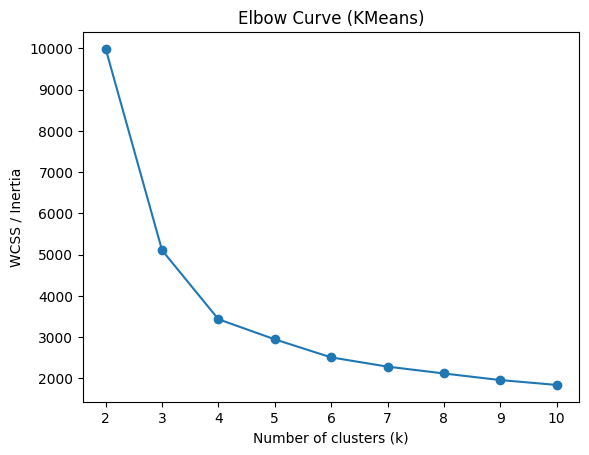

In [6]:

plt.figure()
plt.plot(list(k_values), wcss, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS / Inertia")
plt.title("Elbow Curve (KMeans)")
plt.show()

**Elbow choice:** The curve shows a noticeable bend around k = 4, after which adding more clusters yields smaller reductions in WCSS.

For business use, k=4 is also interpretable (e.g., loyal, big spenders, regulars, inactive).

### Step 5 — Final clustering model (k = 4)

Using k=4 from the elbow method and business interpretability, we fit the final KMeans model and assign each customer a cluster label.
We use fit_predict to both train the model and return the cluster assignment for each row.

In [ ]:
final_k = 4
final_model = KMeans(n_clusters=final_k, random_state=42, n_init=10)

df["cluster"] = final_model.fit_predict(X_scaled)


In [8]:

df["cluster"].value_counts()

cluster
1    1902
0    1536
2    1350
3    1212
Name: count, dtype: int64

### Step 6 — Cluster profiling and interpretation
To interpret clusters, we compute the mean of each segmentation feature by cluster.
This helps translate numeric labels into business segments (e.g., loyal, inactive, high spenders).
We focus on RFM first (recency, orders, order value) and then check whether category mix differs meaningfully.

In [ ]:
cluster_profile = df.groupby("cluster")[seg_cols].mean().round(3)
cluster_profile

,recency_days,orders_last_12m,avg_order_value,cat_share_electronics,cat_share_apparel,cat_share_home,cat_share_beauty,cat_share_groceries,cat_share_sports
cluster,,,,,,,,,
0,549.669,0.999,29.901,0.164,0.166,0.166,0.169,0.165,0.168
1,93.172,5.640,71.287,0.170,0.169,0.164,0.162,0.166,0.170
2,79.601,4.004,205.428,0.175,0.166,0.165,0.169,0.164,0.161
3,57.111,11.619,45.668,0.175,0.176,0.161,0.164,0.166,0.159


**Key segment insights (based on RFM):**

**Cluster 3** — High Frequency Loyal: lowest recency (~57 days) and highest orders (~11.6). Active repeat buyers.

**Cluster 2** — Big Spenders: highest avg order value (~205). Fewer orders than Cluster 3 but very high spend per order.

**Cluster 1** — Mid-tier Regulars: moderate recency (~93) and moderate orders (~5.6) with mid spend (~71).

**Cluster 0** — Inactive / Churned: very high recency (~550) with ~1 order and low spend (~30), indicating churned or one-time buyers.

Category share note: category shares appear similar across clusters, suggesting segmentation is primarily driven by RFM behavior rather than strong differences in category preference.